# EDA · asociación en series temporales

Continuación del 07. Empieza corrigiendo un problema que la corrida del 07 destapó sin querer,
y sigue con cuatro análisis que **la caja de herramientas de la asignatura no puede dar**, porque
está pensada para datos transversales: una fila por individuo, sin orden entre ellas.

## El problema que hay que arreglar primero

En la matriz por familias del 07, la fila «meteorología» sale en **NaN** contra capacidad y
commodities. Y en la matriz de candidatas, «solar prevista» sale en NaN contra gas y CO2.

No es un fallo de código: es que **esas correlaciones se calculan sobre cero filas**.

- ERA5 aterriza en las horas UTC múltiplo de 3 (0, 3, 6… 21).
- Las tablas diarias aterrizan en la hora **00 local**, que en UTC es las 22:00 o las 23:00.
- 22 y 23 no son múltiplos de 3 → **no coinciden nunca**. Solape: 0 filas.

Y el caso de «solar prevista vs gas» es distinto pero igual de revelador: sólo comparten la hora
00 local, y a esa hora la solar prevista vale siempre 0. Varianza cero, correlación indefinida.

**La consecuencia va más allá de dos celdas en blanco.** Cualquier par que mezcle una tabla
horaria con una diaria se está calculando sobre 1 de cada 24 filas, y encima siempre la misma
hora del día — la madrugada. Eso no es una muestra de la relación, es la relación **a las tres de
la mañana**.

**La corrección:** agregar a frecuencia diaria antes de correlacionar. Es el bloque A.

## Índice

| Bloque | Contenido | Por qué no está en las herramientas de clase |
|---|---|---|
| **A** | Correlación sobre datos agregados a diario | Corrige el solape nulo entre granularidades |
| **B** | Correlación cruzada con desfase | El tiempo no existe en datos transversales |
| **C** | Correlación por hora del día | El modelo predice 24 horas, no una media |
| **D** | Correlación móvil: ¿la relación es estable? | Complementa el control por año del 07 |
| **E** | Correlación parcial: ¿directa o confundida? | Distingue causa común de relación propia |

---
## 0 · Carga y marco diario

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

TZ = "Europe/Madrid"
RAIZ = Path.cwd() if (Path.cwd() / "data").exists() else Path.cwd().parent
df = pd.read_parquet(RAIZ / "data" / "bronze" / "bronze_unificado.parquet")
df["ts_utc"] = pd.to_datetime(df["ts_utc"], utc=True)
assert df["ts_utc"].duplicated().sum() == 0, "parquet duplicado: regenerar"

df["ts_local"] = df["ts_utc"].dt.tz_convert(TZ)
df["dia"] = df["ts_local"].dt.date
df["hora"] = df["ts_local"].dt.hour
df["anio"] = df["ts_local"].dt.year

plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.25})

def pick(d, *c):
    for x in c:
        if x is not None and x in d.columns:
            return x
    return None

CALENDARIO = {"hour_utc", "hour_local", "hora", "anio", "tensor_index"}
num = [c for c in df.select_dtypes(include=[np.number]).columns if c not in CALENDARIO]
print(f"{len(num)} columnas numéricas")

91 columnas numéricas


### 0.1 · La prueba del solape nulo

Antes de corregir nada, conviene ver el mecanismo con los datos propios. Si el número de horas
compartidas entre una variable de ERA5 y una diaria es cero, la correlación del 07 entre ellas
no era baja: **no existía**.

In [2]:
ERA5 = pick(df, "era5_t2m_mean")
DIARIA = pick(df, "commodities_gas_ttf_m1", "cap_disp_ccgt_mw")
HORARIA = pick(df, "load_inter_entsoe_load")

if ERA5 and DIARIA:
    solape = df[[ERA5, DIARIA]].dropna()
    print(f"Filas con {ERA5} Y {DIARIA} a la vez: {len(solape):,} de {len(df):,}")
    print(f"Horas UTC en que hay dato diario: "
          f"{sorted(df.loc[df[DIARIA].notna(), 'ts_utc'].dt.hour.unique())}")
    print(f"Horas UTC en que hay dato ERA5:   "
          f"{sorted(df.loc[df[ERA5].notna(), 'ts_utc'].dt.hour.unique())}")
    print("\nNo comparten ninguna hora: por eso el 07 daba NaN.")

if HORARIA and DIARIA:
    s2 = df[[HORARIA, DIARIA]].dropna()
    print(f"\nY una horaria con una diaria sí solapan, pero sólo {len(s2):,} filas "
          f"({len(s2)/len(df)*100:.1f}%),")
    print(f"todas a la hora local 0. Eso no mide la relación: mide la relación de madrugada.")

Filas con era5_t2m_mean Y commodities_gas_ttf_m1 a la vez: 0 de 58,319
Horas UTC en que hay dato diario: [np.int32(22), np.int32(23)]
Horas UTC en que hay dato ERA5:   [np.int32(0), np.int32(3), np.int32(6), np.int32(9), np.int32(12), np.int32(15), np.int32(18), np.int32(21)]

No comparten ninguna hora: por eso el 07 daba NaN.

Y una horaria con una diaria sí solapan, pero sólo 1,702 filas (2.9%),
todas a la hora local 0. Eso no mide la relación: mide la relación de madrugada.


## A · Correlación sobre datos diarios

**La corrección.** Se agrega todo a día: media para las variables de nivel, y para las diarias
basta con tomar el único valor no nulo del día. Así todas las series viven en la misma
frecuencia y cada par se calcula sobre las ~2.430 fechas completas, no sobre un 4 % sesgado.

**Lo que se pierde y por qué compensa.** Se pierde el detalle intradiario, que es real e
importante — pero eso lo cubre el bloque C, que mira la correlación hora a hora. Aquí interesa
la relación entre magnitudes diarias, que es además la escala a la que se toman muchas
decisiones del sistema.

In [3]:
# Agregación: media diaria ignorando NaN. Para las columnas diarias eso devuelve
# su único valor del día, así que sirve para todas por igual.
DIA = df.groupby("dia")[num].mean()
DIA.index = pd.to_datetime(DIA.index)
DIA["anio"] = DIA.index.year
print(f"Marco diario: {DIA.shape[0]:,} días x {DIA.shape[1]} columnas")

cobertura = DIA[num].notna().mean().mul(100).round(1)
print("\nCobertura tras agregar (antes de agregar, las diarias tenían ~4%):")
display(cobertura.sort_values().head(10).rename("% días con dato").to_frame())

Marco diario: 2,430 días x 92 columnas

Cobertura tras agregar (antes de agregar, las diarias tenían ~4%):


,% días con dato
esios_gen_ree_gbattery_mw,25.5
esios_gen_ree_cbattery_mw,25.5
cap_inst_battery_hybrid_mw,39.9
cap_inst_wind_hybrid_mw,41.2
cap_inst_solar_pv_hybrid_mw,48.7
cap_inst_autoconsume_battery_mw,50.0
entsoe_pumping_gen_mw,56.2
commodities_co2_eua_dec,69.8
commodities_gas_ttf_m1,70.1
era5_wind_gust10_mean,97.9


In [4]:
Cd = DIA[num].corr()
Ch = df[num].corr()

# ¿Cuántos pares pasan de indefinidos a calculables?
antes = Ch.isna().sum().sum()
despues = Cd.isna().sum().sum()
print(f"Celdas NaN en la matriz HORARIA: {antes:,}")
print(f"Celdas NaN en la matriz DIARIA:  {despues:,}")
print(f"Pares recuperados: {(antes - despues)//2:,}")

# Y de los que ya existían, ¿cuánto cambian?
m = np.triu(np.ones(Cd.shape, dtype=bool), k=1)
comp = pd.DataFrame({
    "horaria": Ch.where(m).stack(),
    "diaria": Cd.where(m).stack(),
}).dropna()
comp["dif"] = (comp["diaria"] - comp["horaria"]).abs()
print(f"\nPares comparables: {len(comp):,} · diferencia media |Δr|: {comp['dif'].mean():.4f}")
print("Pares donde más cambia la conclusión al agregar a diario:")
display(comp.sort_values("dif", ascending=False).head(12).round(4))

Celdas NaN en la matriz HORARIA: 1,488
Celdas NaN en la matriz DIARIA:  1,068
Pares recuperados: 210

Pares comparables: 3,354 · diferencia media |Δr|: 0.0856
Pares donde más cambia la conclusión al agregar a diario:


horaria  diaria     dif
cap_inst_solar_pv_mw             calc_autoconsumo_mw            -0.4579  0.5450  1.0028
cap_inst_autoconsume_solar_pv_mw calc_autoconsumo_mw            -0.4807  0.5087  0.9894
cap_inst_wind_mw                 calc_autoconsumo_mw            -0.5321  0.4390  0.9711
esios_gen_ree_gbattery_mw        esios_gen_ree_cbattery_mw       0.0826 -0.8237  0.9063
entsoe_pumping_gen_mw            esios_gen_ree_gsolar_mw        -0.5223  0.3189  0.8411
cap_inst_waste_nonrenewable_mw   calc_autoconsumo_mw             0.4811 -0.3566  0.8378
cap_inst_coal_mw                 calc_autoconsumo_mw             0.5306 -0.2944  0.8250
entsoe_pumping_gen_mw            calc_solar_fv_mw               -0.5382  0.2868  0.8249
                                 forecast_gen_solar_pv_prev_mw  -0.5246  0.2838  0.8084
entsoe_solar_mw                  entsoe_pumping_gen_mw          -0.5318  0.2584  0.7903
cap_inst_cogeneration_mw         calc_autoconsumo_mw             0.1547 -0.6242  0.7788
cap_inst_other_renewable_mw      calc_autoconsumo_mw            -0.1989  0.5289  0.7277

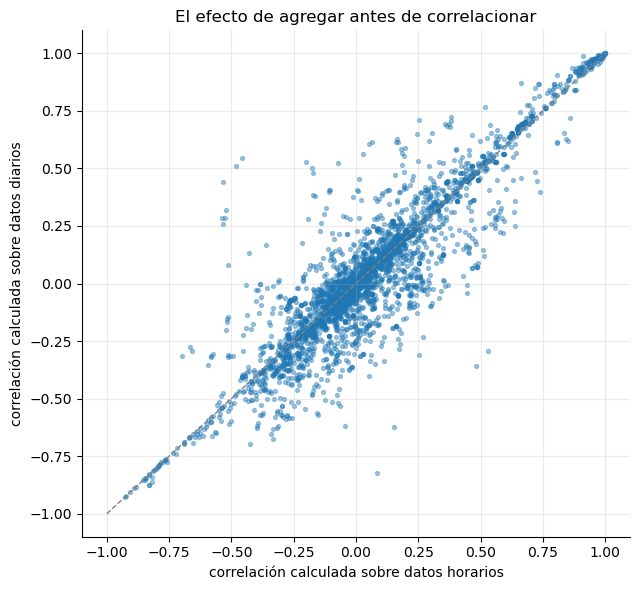

Los puntos lejos de la diagonal son pares cuya lectura cambia según la frecuencia.
Ninguna de las dos es 'la correcta': responden a preguntas distintas, y hay que
decir cuál se usa. Lo que no vale es la matriz horaria para pares diarios.


In [5]:
fig, ax = plt.subplots(figsize=(6.5, 6))
ax.scatter(comp["horaria"], comp["diaria"], s=8, alpha=0.4)
ax.plot([-1, 1], [-1, 1], color="grey", ls="--", lw=1)
ax.set_xlabel("correlación calculada sobre datos horarios")
ax.set_ylabel("correlación calculada sobre datos diarios")
ax.set_title("El efecto de agregar antes de correlacionar")
plt.tight_layout(); plt.show()
print("Los puntos lejos de la diagonal son pares cuya lectura cambia según la frecuencia.")
print("Ninguna de las dos es 'la correcta': responden a preguntas distintas, y hay que")
print("decir cuál se usa. Lo que no vale es la matriz horaria para pares diarios.")

---
## B · Correlación cruzada con desfase

**Qué añade.** Una correlación contemporánea sólo pregunta si dos series se mueven a la vez. En
un sistema con inercia —embalses que se gestionan por semanas, gas que se contrata con
antelación, temperatura que arrastra la demanda con retraso— **la relación puede estar
desplazada en el tiempo**.

**Por qué las herramientas de clase no lo cubren.** En datos transversales no hay orden entre
filas, así que el concepto de desfase no existe. Es específico de series temporales, y aquí es
directamente accionable: el desfase que maximiza la asociación **es el lag que hay que meter como
feature**.

**Y conecta con la frontera de fuga.** Si el desfase óptimo es 0, la variable sólo sirve
contemporánea — y si tiene fuga, no sirve. Si el óptimo es −1 día o más, la versión retardada es
utilizable y además es la que más información aporta.

In [6]:
def corr_desfases(a, b, lags):
    '''
    Correlación de a(t) con b(t-lag).

    CONVENCIÓN, verificada con una relación sintética de desfase conocido:
    lag POSITIVO = el driver adelanta al objetivo, o sea que b(t-3) explica a(t).
    Ese es justamente el caso utilizable: un valor de hace 3 días ya existe a las
    12:00 de D, aunque la variable contemporánea tenga fuga.
    '''
    out = {}
    for k in lags:
        out[k] = a.corr(b.shift(k))
    return pd.Series(out)

OBJ = pick(DIA, "spot_es_omie", "es_omie", "load_inter_entsoe_load")
print(f"Serie de referencia: {OBJ}")

CANDIDATOS = [c for c in [
    pick(DIA, "era5_t2m_mean"), pick(DIA, "era5_wind100_mean"), pick(DIA, "era5_ssrd_mean"),
    pick(DIA, "commodities_gas_ttf_m1"), pick(DIA, "commodities_co2_eua_dec"),
    pick(DIA, "calc_solar_fv_mw"), pick(DIA, "entsoe_wind_mw"),
    pick(DIA, "calc_hydro_dispatch_mw"), pick(DIA, "cap_disp_ccgt_mw"),
] if c and c != OBJ]

LAGS = range(-7, 8)
tabla = {}
for c in CANDIDATOS:
    s = corr_desfases(DIA[OBJ], DIA[c], LAGS)
    tabla[c] = s
X = pd.DataFrame(tabla)

resumen = pd.DataFrame({
    "r en lag 0": X.loc[0],
    "mejor r": X.apply(lambda s: s.loc[s.abs().idxmax()]),
    "lag óptimo (días)": X.apply(lambda s: s.abs().idxmax()),
})
resumen["ganancia"] = resumen["mejor r"].abs() - resumen["r en lag 0"].abs()
display(resumen.sort_values("ganancia", ascending=False).round(4))
print("\n'ganancia' alta = la relación está desplazada en el tiempo y la versión contemporánea")
print("la infravalora. Ese lag es candidato directo a feature.")

Serie de referencia: spot_es_omie


,r en lag 0,mejor r,lag óptimo (días),ganancia
calc_hydro_dispatch_mw,-0.3065,-0.4391,-5,0.1326
calc_solar_fv_mw,-0.0717,-0.1168,-5,0.0451
era5_ssrd_mean,-0.0922,-0.1275,-7,0.0353
era5_t2m_mean,-0.0022,0.0159,7,0.0137
cap_disp_ccgt_mw,0.1511,0.1624,4,0.0112
commodities_co2_eua_dec,0.4476,0.4563,-7,0.0087
era5_wind100_mean,-0.2299,-0.2299,0,0.0000
commodities_gas_ttf_m1,0.6580,0.6580,0,0.0000
entsoe_wind_mw,-0.1776,-0.1776,0,0.0000



'ganancia' alta = la relación está desplazada en el tiempo y la versión contemporánea
la infravalora. Ese lag es candidato directo a feature.


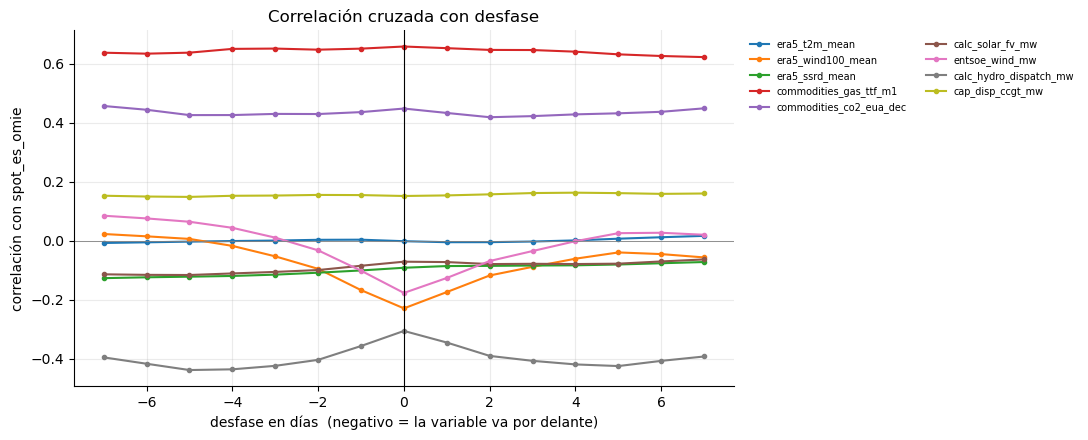

Un pico en lag 0 = relación instantánea. Un pico desplazado = inercia del sistema,
y además una feature utilizable aunque la variable original tenga fuga.


In [7]:
fig, ax = plt.subplots(figsize=(11, 4.5))
for c in X.columns:
    ax.plot(X.index, X[c], marker="o", ms=3, label=c[:28])
ax.axvline(0, color="black", lw=0.8)
ax.axhline(0, color="grey", lw=0.6)
ax.set_xlabel("desfase en días  (negativo = la variable va por delante)")
ax.set_ylabel(f"correlación con {OBJ[:24]}")
ax.set_title("Correlación cruzada con desfase")
ax.legend(frameon=False, fontsize=7, ncol=2, bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout(); plt.show()

print("Un pico en lag 0 = relación instantánea. Un pico desplazado = inercia del sistema,")
print("y además una feature utilizable aunque la variable original tenga fuga.")

---
## C · Correlación por hora del día

**Qué añade, y por qué importa en este TFM concretamente.** El modelo no predice un valor diario:
predice **las 24 horas de D+1**. Si la relación entre un driver y el objetivo cambia según la
hora —y con la fotovoltaica cambia radicalmente— una correlación única promedia cosas distintas
y se queda en un número intermedio que no describe ninguna hora.

**Consecuencia práctica.** Si un driver sólo importa en unas horas concretas, hay dos caminos:
entrenar un modelo por hora, o incluir la interacción hora × driver. Esta figura dice cuál de
los dos hace falta y para qué variables.

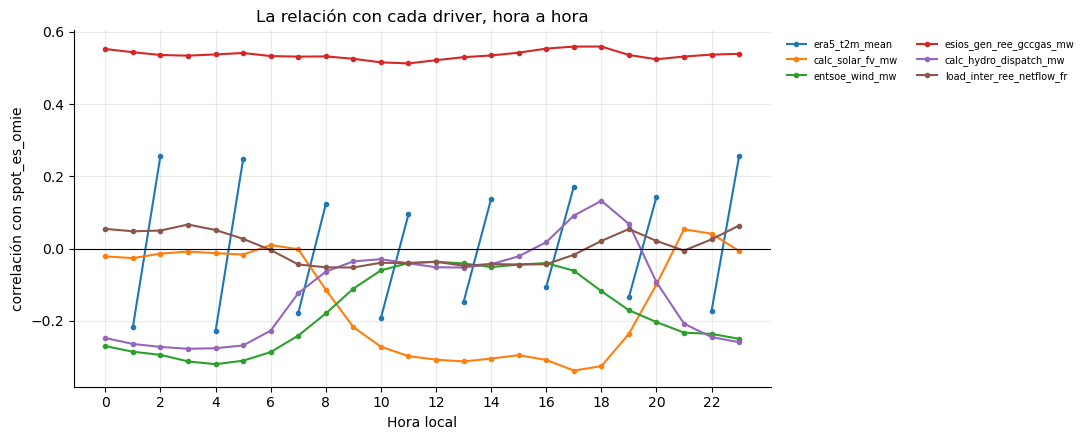

,amplitud,r medio
era5_t2m_mean,0.4853,0.0032
calc_hydro_dispatch_mw,0.4096,-0.1163
calc_solar_fv_mw,0.3908,-0.1430
entsoe_wind_mw,0.2835,-0.1748
load_inter_ree_netflow_fr,0.1189,0.0005
esios_gen_ree_gccgas_mw,0.0467,0.5357



Amplitud grande = la correlación única de las matrices anteriores es un promedio
que no describe ninguna hora concreta. Ahí hace falta interacción con la hora.


In [8]:
DRIVERS_H = [c for c in [
    pick(df, "era5_t2m_mean"), pick(df, "calc_solar_fv_mw"), pick(df, "entsoe_wind_mw"),
    pick(df, "esios_gen_ree_gccgas_mw"), pick(df, "calc_hydro_dispatch_mw"),
    pick(df, "load_inter_ree_netflow_fr"),
] if c]
OBJ_H = pick(df, "spot_es_omie", "es_omie", "load_inter_entsoe_load")
DRIVERS_H = [c for c in DRIVERS_H if c != OBJ_H]

por_hora = pd.DataFrame(
    {c: df.groupby("hora").apply(lambda g: g[OBJ_H].corr(g[c]), include_groups=False)
     for c in DRIVERS_H})

fig, ax = plt.subplots(figsize=(11, 4.5))
for c in por_hora.columns:
    ax.plot(por_hora.index, por_hora[c], marker="o", ms=3, label=c[:30])
ax.axhline(0, color="black", lw=0.8)
ax.set_xlabel("Hora local"); ax.set_ylabel(f"correlación con {OBJ_H[:22]}")
ax.set_xticks(range(0, 24, 2))
ax.set_title("La relación con cada driver, hora a hora")
ax.legend(frameon=False, fontsize=7, ncol=2, bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout(); plt.show()

rango = (por_hora.max() - por_hora.min()).rename("amplitud").to_frame()
rango["r medio"] = por_hora.mean()
display(rango.sort_values("amplitud", ascending=False).round(4))
print("\nAmplitud grande = la correlación única de las matrices anteriores es un promedio")
print("que no describe ninguna hora concreta. Ahí hace falta interacción con la hora.")

---
## D · Correlación móvil

**Qué añade sobre el bloque C del 07.** Allí se comparaba la correlación global con la media
anual, que da un número. Aquí se ve la **trayectoria**: una ventana móvil de 90 días muestra si
la relación se mantiene, se degrada o cambia de signo, y **cuándo**.

**Por qué importa para el modelado.** Una relación que se debilita con el tiempo hace que
entrenar con todo el histórico sea contraproducente: el modelo aprende un régimen que ya no
existe. Y si la ruptura coincide con una fecha conocida —el tope al gas, el apagón, la entrada
del autoconsumo— la explicación es estructural y hay que tratarla, no promediarla.

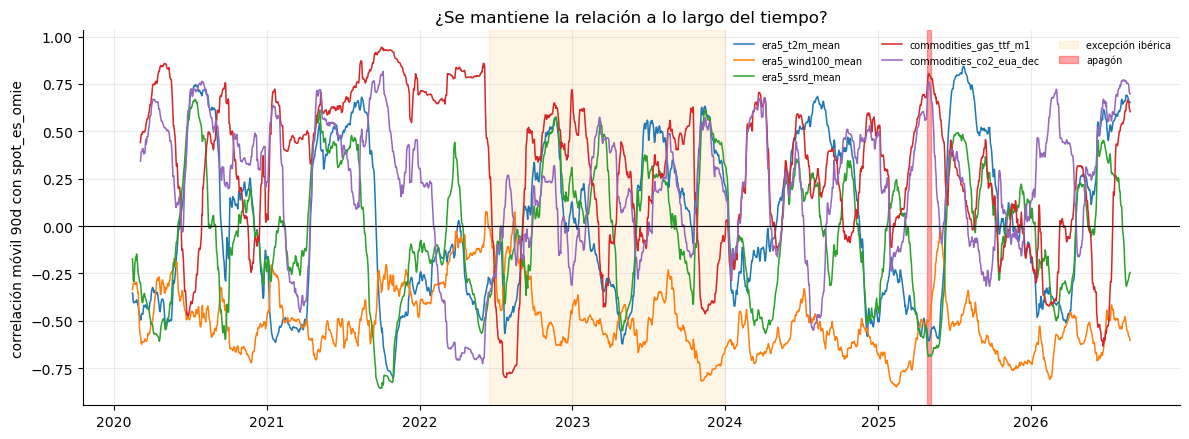

Una banda estrecha alrededor de un nivel = relación estable.
Cambios de signo o saltos coincidiendo con los períodos marcados = régimen distinto,
y eso es un argumento para marcarlo con una dummy o para acotar el histórico.


In [9]:
VENTANA = 90   # días
PARES_D = [(OBJ, c) for c in CANDIDATOS[:5]]

fig, ax = plt.subplots(figsize=(12, 4.5))
for a, b in PARES_D:
    s = DIA[a].rolling(VENTANA, min_periods=VENTANA // 2).corr(DIA[b])
    ax.plot(s.index, s.values, lw=1.1, label=b[:28])
ax.axhline(0, color="black", lw=0.8)
ax.axvspan(pd.Timestamp("2022-06-15"), pd.Timestamp("2023-12-31"),
           alpha=0.10, color="orange", label="excepción ibérica")
ax.axvspan(pd.Timestamp("2025-04-28"), pd.Timestamp("2025-05-06"),
           alpha=0.35, color="red", label="apagón")
ax.set_ylabel(f"correlación móvil {VENTANA}d con {OBJ[:20]}")
ax.set_title("¿Se mantiene la relación a lo largo del tiempo?")
ax.legend(frameon=False, fontsize=7, ncol=3)
plt.tight_layout(); plt.show()

print("Una banda estrecha alrededor de un nivel = relación estable.")
print("Cambios de signo o saltos coincidiendo con los períodos marcados = régimen distinto,")
print("y eso es un argumento para marcarlo con una dummy o para acotar el histórico.")

---
## E · Correlación parcial: ¿directa o confundida?

**El problema que resuelve.** Dos variables pueden correlacionar porque una causa a la otra, o
porque **ambas dependen de una tercera**. El caso de manual en este sistema: la solar y la
temperatura correlacionan, pero en buena parte porque ambas siguen el ciclo estacional y el
ciclo diario. Descontar esos ciclos deja la relación que queda por sí misma.

**Cómo se calcula.** La correlación parcial entre A y B controlando por C es la correlación de
los **residuos** de regresar A sobre C y B sobre C. Si cae mucho respecto a la correlación
simple, buena parte de lo que veíamos era la tercera variable.

**Los controles naturales aquí** son el mes (estacionalidad) y la hora (ciclo diario), que
explican una fracción enorme de casi todo en un sistema eléctrico.

In [10]:
from numpy.linalg import lstsq

def residuos(y, X):
    '''Residuos de y tras quitar el efecto de X (con constante).'''
    d = pd.concat([y, X], axis=1).dropna()
    if len(d) < 100:
        return None
    yy = d.iloc[:, 0].to_numpy()
    XX = np.column_stack([np.ones(len(d)), d.iloc[:, 1:].to_numpy()])
    beta, *_ = lstsq(XX, yy, rcond=None)
    return pd.Series(yy - XX @ beta, index=d.index)

# Controles: armónicos de mes y hora, que capturan los dos ciclos sin imponer forma lineal.
base = df[["hora"]].copy()
base["mes"] = df["ts_local"].dt.month
CTRL = pd.DataFrame({
    "sin_h": np.sin(2 * np.pi * base["hora"] / 24),
    "cos_h": np.cos(2 * np.pi * base["hora"] / 24),
    "sin_m": np.sin(2 * np.pi * base["mes"] / 12),
    "cos_m": np.cos(2 * np.pi * base["mes"] / 12),
}, index=df.index)

filas = []
for c in DRIVERS_H:
    simple = df[OBJ_H].corr(df[c])
    ra = residuos(df[OBJ_H], CTRL)
    rb = residuos(df[c], CTRL)
    if ra is None or rb is None:
        continue
    comun = ra.index.intersection(rb.index)
    parcial = ra.loc[comun].corr(rb.loc[comun])
    filas.append({"driver": c, "r simple": simple, "r parcial": parcial,
                  "% que era ciclo": (1 - abs(parcial) / max(abs(simple), 1e-9)) * 100})

P = pd.DataFrame(filas).set_index("driver")
display(P.sort_values("% que era ciclo", ascending=False).round(4))
print("\n'% que era ciclo' alto = la asociación venía en su mayoría de la estacionalidad y del")
print("ciclo diario, no de la variable en sí. Un modelo que ya incluye hora y mes no ganará")
print("mucho añadiendo ese driver.")

,r simple,r parcial,% que era ciclo
driver,,,
load_inter_ree_netflow_fr,0.0164,-0.0042,74.6970
calc_hydro_dispatch_mw,0.0285,0.0185,34.9114
calc_solar_fv_mw,-0.2628,-0.2401,8.6138
esios_gen_ree_gccgas_mw,0.5613,0.5486,2.2644
entsoe_wind_mw,-0.1287,-0.1882,-46.2431
era5_t2m_mean,-0.0415,-0.0821,-97.7047



'% que era ciclo' alto = la asociación venía en su mayoría de la estacionalidad y del
ciclo diario, no de la variable en sí. Un modelo que ya incluye hora y mes no ganará
mucho añadiendo ese driver.


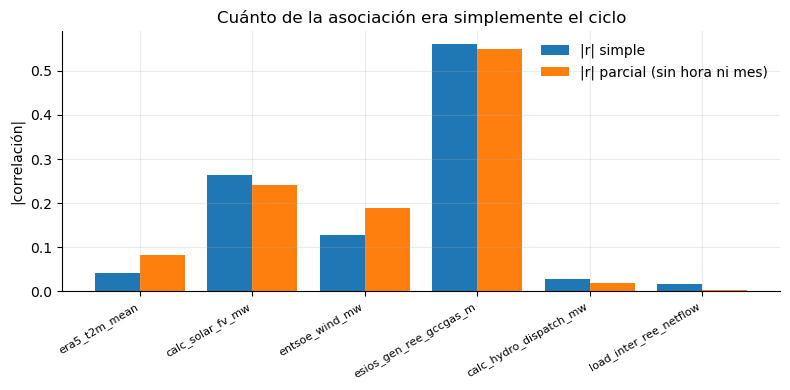

In [11]:
fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(P))
ax.bar(x - 0.2, P["r simple"].abs(), width=0.4, label="|r| simple")
ax.bar(x + 0.2, P["r parcial"].abs(), width=0.4, label="|r| parcial (sin hora ni mes)")
ax.set_xticks(x, [c[:22] for c in P.index], rotation=30, ha="right", fontsize=8)
ax.set_ylabel("|correlación|"); ax.legend(frameon=False)
ax.set_title("Cuánto de la asociación era simplemente el ciclo")
plt.tight_layout(); plt.show()

---
## Cierre

In [12]:
for l in [
    "QUÉ APORTA ESTE NOTEBOOK SOBRE EL 07",
    "=" * 66,
    "",
    "A · Corrige un error de método, no un detalle de presentación. Los pares que",
    "    mezclan una tabla horaria con una diaria se calculaban sobre 1 de cada 24",
    "    filas -- siempre la madrugada -- y los que mezclaban ERA5 con diaria, sobre",
    "    CERO filas. Agregando a diario, cada par usa las ~2.430 fechas completas.",
    "",
    "B · El desfase óptimo de cada driver. Es información directamente accionable:",
    "    ese lag es el que hay que meter como feature, y una variable con fuga puede",
    "    seguir siendo útil en su versión retardada.",
    "",
    "C · La correlación hora a hora. El modelo predice 24 horas, no una media: si la",
    "    amplitud es grande, una correlación única no describe ninguna hora concreta.",
    "",
    "D · La trayectoria de la relación, no sólo su promedio. Dice CUÁNDO se rompe, y",
    "    si coincide con un régimen conocido.",
    "",
    "E · Cuánta de la asociación era estacionalidad y ciclo diario. Un driver cuya",
    "    correlación se desploma al controlar por hora y mes no aporta sobre un",
    "    modelo que ya los incluye.",
    "",
    "Ninguno de los cinco está en FuncionesMineria.py, y no por descuido: aquella caja",
    "de herramientas es para datos transversales, donde no hay orden entre filas y por",
    "tanto no existen ni el desfase, ni la ventana móvil, ni el ciclo diario.",
    "",
    "PENDIENTE: rehacer todo con spot_price como serie de referencia. Con la demanda",
    "como sustituta las técnicas quedan validadas, pero las conclusiones sobre el",
    "PRECIO hay que volver a sacarlas.",
]:
    print(l)

QUÉ APORTA ESTE NOTEBOOK SOBRE EL 07

A · Corrige un error de método, no un detalle de presentación. Los pares que
    mezclan una tabla horaria con una diaria se calculaban sobre 1 de cada 24
    filas -- siempre la madrugada -- y los que mezclaban ERA5 con diaria, sobre
    CERO filas. Agregando a diario, cada par usa las ~2.430 fechas completas.

B · El desfase óptimo de cada driver. Es información directamente accionable:
    ese lag es el que hay que meter como feature, y una variable con fuga puede
    seguir siendo útil en su versión retardada.

C · La correlación hora a hora. El modelo predice 24 horas, no una media: si la
    amplitud es grande, una correlación única no describe ninguna hora concreta.

D · La trayectoria de la relación, no sólo su promedio. Dice CUÁNDO se rompe, y
    si coincide con un régimen conocido.

E · Cuánta de la asociación era estacionalidad y ciclo diario. Un driver cuya
    correlación se desploma al controlar por hora y mes no aporta sobre un
    